# OT-2: Turbine Stage Profiling

In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
from turborocket.profiling.Supersonic.supersonic_profile import SupersonicProfile

from turborocket.profiling.Supersonic.circular import inv_M_star

from turborocket.fluids.fluids import IdealGas

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import yaml


Author: Elias Aoubala

Date:

## 1 - Background

This document contains the authors analysis and methodology for the profiling of the OT-2: `Man-Ray and the Dirty Bubble` turbopump supersonic turbine stage. The `turboRocket` profiling submodule within python is used for the profiling, following a modified method for profile generation based on the `Goodman et Al.` approach, with the addition of the following:

- Adjusted blade-spacing to account for boundary layer effects.
- Finited wedge leading edge to improve manufacturability of profiles.

The overall method for the profiling of the turbine is as folloed:
- Symmetric blades are used.
- Straight Wedge Leading and Trailing Edges are used protruding from suction surface.
- Unique Incidence Prantle Meyer Expansion Fans are accounted for true inlet conditions of the profile (due to the leading/trailing edge of the turbine).
- Straigh entrance and exit is used on the suction surface of the turbine.
- Free-vortex flow assumption is used for the design of the central turning mid section of blade.
- Method of Characteristics implemented for the transition points to the straigh inlet/exit sections.

The use must define the high-level directory which specifies where the meanline parameters are:

In [3]:
meanline_directory = "config"

## 2 - Importing our Meanline Design Parameters

The first thing we need to do is import our results and requirements we evaluated for from our mean-line design conducted in `turbine_mean_design.ipynb` document. We firstly decl

In [4]:
with open(f"{meanline_directory}/turbine_out.yaml") as f:

    meanline = yaml.safe_load(f)

## 3 - Loading The Combustion Gas Properties

We must also load in our combustion gas properties and instantiate our `IdealGas` fluid object for use in the profiling.

In [5]:
with open(f"{meanline_directory}/gg_out.yaml") as f:

    gg_inputs = yaml.safe_load(f)

We can extract our gas object properties accordingly.

In [6]:
gas_dic = gg_inputs["gas_generator"]["operating_point"]["gas"]

fluid = IdealGas(
    name="GG Exhaust",
    p=gas_dic["P"],
    t=gas_dic["T"],
    gamma=gas_dic["gamma"],
    cp=gas_dic["cp"],
    R=gas_dic["R"],
)

## 4 - Profile Design

Here we can generate our turbine blade profile, by using the "profiling" submodule of the `turborocket` python package.

A reasonable blade leading edge has been assumed for this analysis.

A reverse computation is performed to evaluate for the inlet mach number, based on the inlet M_star number.

We will assume a given number of blades at this stage.

### 3.1 - Profile Object Instantiation

We can instantiate our turbo rocket file as the following:

In [7]:
M_i = inv_M_star(M_star=meanline["mach"]["m_star_w1"], gamma=fluid.gamma)
print(f"M_i: {M_i}")
super = SupersonicProfile(
    beta = (-(90 - meanline["angles"]["beta_1"]), (90 - meanline["angles"]["beta_1"])),
    M_r = (M_i, M_i+0.2),
    M_s = (1.33, 2.2),
    t_g_rat=0.12,
    g_expand=0.2,
    k_max=50,
    fluid = fluid,
)

M_i: 1.7880497623425993
1.276616659585316
################################################################################
#                              Constraint Report                               #
################################################################################

M_i_star: 1.6031482651928424
M_i_star_max: 1.6770136596999

M_u_star: 1.276616659585316
M_u_star_min: 1.2706210666296758

M_l_star: 1.8420487058391197
M_l_star_max: 2.057354070653593


### 3.2 - Profile Sizing

Now that we have generated our profile, we can size the profile based on the mean diameter and shaft speed of the turbine stage.

We will firstly extract our tip, mean and root diameters, along with the number of blades.

In [8]:
D_hub = meanline["geometry"]["D_hub"]
D_m = meanline["geometry"]["D_m"]
D_tip = meanline["geometry"]["D_tip"]

print(f"D_hub: {D_hub*1e2:.2f} cm")
print(f"D_tip: {D_tip*1e2:.2f} cm")

N_blade = meanline["input"]["rotor"]["N_rotor"]

D_hub: 8.80 cm
D_tip: 11.04 cm


In [9]:
sf = super.size_geometry(D_m=D_m, N=N_blade)

print(f"Calculated Scaling Factor: {sf}")

Calculated Scaling Factor: 0.006942397425962136


### 3.3 - Generating our CFD Blade Passage

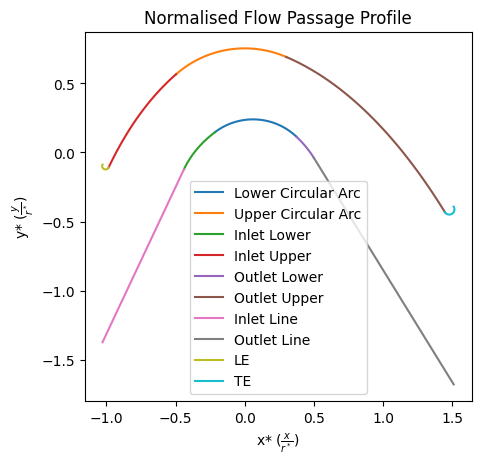

In [21]:
super.plot_passage()


We can get the blade passage spacing and figure out our L/D of the geometry

### 3.4 - Plotting Our Profile

Finally we can plot the scaled geometry

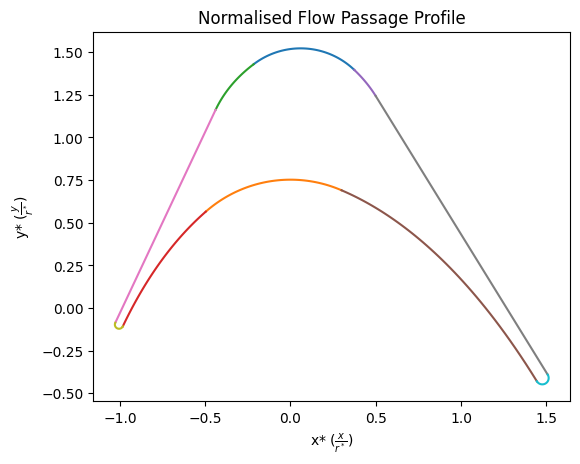

In [39]:
super.plot_blade()

### 3.5 - Generating Our Profile CAD

We can then generate our blade file

In [12]:
k = super.generate_xy(sf=sf*1e3)

k.to_csv(f"{meanline_directory}/blade.txt", sep="\t", index=False, header=False)


## 5 - Generating Our CFD Profiles

We can now generate our CFD profiles

In [51]:
df_1, df_2 = super.generate_cfd()